In [1]:
import torch
print("torch", torch.__version__)


torch 2.7.0+cu126


In [2]:
import torch

*   https://pytorch.org/blog/quantization-in-practice/
*   https://pytorch.org/docs/stable/quantization.html
*   https://pytorch.org/docs/stable/quantization-support.html

### Mapping function and Quantization Parameters

In [3]:
# r - float tensor, r' - int tensor
# S [scaling factor] = (beta - alpha) / (beta_q - alpha_q)
# Z [zero point] =  -(alpha / S - alpha_q)

def quantize(float_tensor, scale, z):
  # Q(r) = round(r/S + Z)
  return torch.round(float_tensor / scale + z)

def dequantize(int_tensor, scale, z):
  # r' = (Q(r) - Z) * S
  return (int_tensor - z) * scale

In [4]:
from torch.ao.quantization.observer import MinMaxObserver, MovingAverageMinMaxObserver, HistogramObserver

C, L = 3, 4
normal = torch.distributions.normal.Normal(0,1)
inputs = normal.sample((C, L))
print(inputs)

tensor([[-1.1047, -1.9951,  1.0431, -0.0202],
        [-1.3907, -0.5346,  0.8298,  0.5258],
        [ 0.5072,  1.8766, -2.2414,  0.1193]])


In [5]:
observers = [MinMaxObserver(), MovingAverageMinMaxObserver(), HistogramObserver()]
for obs in observers:
  obs(inputs)
  print(obs.__class__.__name__, obs.calculate_qparams())

MinMaxObserver (tensor([0.0161]), tensor([139], dtype=torch.int32))
MovingAverageMinMaxObserver (tensor([0.0161]), tensor([139], dtype=torch.int32))
HistogramObserver (tensor([0.0161]), tensor([139], dtype=torch.int32))


In [6]:
scale, z = observers[0].calculate_qparams()
reconstruction_error = torch.abs(dequantize(quantize(inputs, scale, z), scale, z) - inputs)
reconstruction_error

tensor([[0.0066, 0.0074, 0.0065, 0.0041],
        [0.0019, 0.0017, 0.0062, 0.0071],
        [0.0065, 0.0033, 0.0033, 0.0063]])

### Affine and Symmetric Quantization Schemes

In [7]:
import numpy as np
import matplotlib.pyplot as plt


def get_symmetric_range(x):
  beta = torch.max(x.max(), x.min().abs())
  return -beta.item(), beta.item()

def get_affine_range(x):
  return x.min().item(), x.max().item()

def plot(plt, data, scheme):
  boundaries = get_affine_range(data) if scheme == 'affine' else get_symmetric_range(data)
  a, _, _ = plt.hist(data, density=True, bins=100)
  ymin, ymax = np.quantile(a[a>0], [0.25, 0.95])
  plt.vlines(x=boundaries, ls='--', colors='purple', ymin=ymin, ymax=ymax)

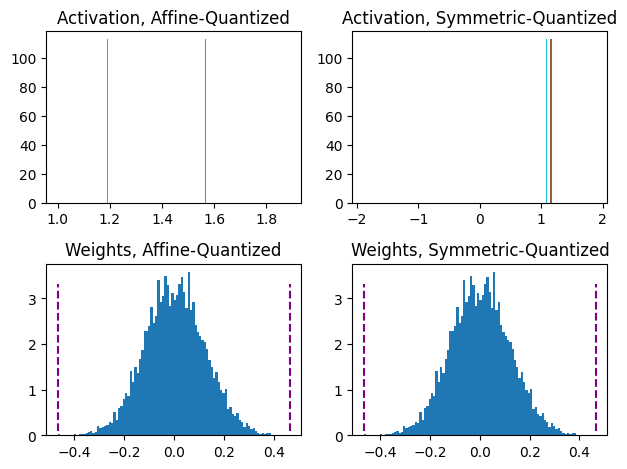

In [8]:
act =  torch.distributions.pareto.Pareto(1, 10).sample((1, 1024))
weights = torch.distributions.normal.Normal(0, 0.12).sample((3, 64, 7, 7)).flatten()

fig, axs = plt.subplots(2,2)
plot(axs[0, 0], act, 'affine')
axs[0, 0].set_title("Activation, Affine-Quantized")

plot(axs[0, 1], act, 'symmetric')
axs[0, 1].set_title("Activation, Symmetric-Quantized")

plot(axs[1, 0], weights, 'affine')
axs[1, 0].set_title("Weights, Affine-Quantized")

plot(axs[1, 1], weights, 'symmetric')
axs[1, 1].set_title("Weights, Symmetric-Quantized")

fig.tight_layout()
plt.show()

In [9]:
for qscheme in [torch.per_tensor_affine, torch.per_tensor_symmetric]:
  obs = MovingAverageMinMaxObserver(qscheme=qscheme)
  obs(inputs)
  print(f"Qscheme: {qscheme} | {obs.calculate_qparams()}")

Qscheme: torch.per_tensor_affine | (tensor([0.0161]), tensor([139], dtype=torch.int32))
Qscheme: torch.per_tensor_symmetric | (tensor([0.0176]), tensor([128]))


### Per-Tensor and Per-Channel Quantization Schemes

In [10]:
from torch.ao.quantization.observer import MovingAveragePerChannelMinMaxObserver

obs = MovingAveragePerChannelMinMaxObserver(ch_axis = 0)  # calculate qparams for all `C` channels separately
obs(inputs)
print(obs.calculate_qparams())

(tensor([0.0119, 0.0087, 0.0161]), tensor([167, 160, 139], dtype=torch.int32))


For weights quantization, symmetric-per-channel quantization provides better accuracies; per-tensor quantization performs poorly, possibly due to high variance in conv weights across channels from batchnorm folding.
[https://arxiv.org/abs/2004.09602]

https://github.com/pytorch/pytorch/blob/748d9d24940cd17938df963456c90fa1a13f3932/torch/ao/quantization/observer.py#L258

### Backend Engine

In [11]:
backend = 'fbgemm' #'fbgemm' if x86 else 'qnnpack' intel - oneDNN
qconfig = torch.ao.quantization.get_default_qconfig(backend)
torch.backends.quantized.engine = backend

GPUs - via TensorRT and cuDNN
https://pytorch.org/docs/stable/quantization.html#note-for-native-cpu-backends

### QConfig

In [12]:
my_qconfig = torch.ao.quantization.QConfig(
  activation=MovingAverageMinMaxObserver.with_args(qscheme=torch.per_tensor_affine),
  weight=MovingAveragePerChannelMinMaxObserver.with_args(qscheme=torch.qint8))

my_qconfig

QConfig(activation=functools.partial(<class 'torch.ao.quantization.observer.MovingAverageMinMaxObserver'>, qscheme=torch.per_tensor_affine){}, weight=functools.partial(<class 'torch.ao.quantization.observer.MovingAveragePerChannelMinMaxObserver'>, qscheme=torch.qint8){})

In [13]:
import torch.nn as nn
# Небольшой пример: повесить свой qconfig на конкретный слой


class Tiny(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(16, 16)

    def forward(self, x):
        return self.fc(x)


tiny = Tiny()
tiny.fc.qconfig = my_qconfig
tiny.fc.qconfig


QConfig(activation=functools.partial(<class 'torch.ao.quantization.observer.MovingAverageMinMaxObserver'>, qscheme=torch.per_tensor_affine){}, weight=functools.partial(<class 'torch.ao.quantization.observer.MovingAveragePerChannelMinMaxObserver'>, qscheme=torch.qint8){})

### Eager Mode v/s FX Graph Mode

*    Eager Mode Quantization is a beta feature. User needs to do fusion and specify where quantization and dequantization happens manually, also it only supports modules and not functionals.
*    FX Graph Mode Quantization is a new automated quantization framework in PyTorch, and currently it’s a prototype feature. It improves upon Eager Mode Quantization by adding support for functionals and automating the quantization process, although people might need to refactor the model to make the model compatible with FX Graph Mode Quantization (symbolically traceable with torch.fx)






FX Graph Mode automatically fuses eligible modules, inserts Quant/DeQuant stubs, calibrates the model and returns a quantized module - all in two method calls - but only for networks that are symbolic traceable. The examples below contain the calls using Eager Mode and FX Graph Mode for comparison.
https://pytorch.org/docs/stable/fx.html#torch.fx.symbolic_trace

In [14]:
def f(a, b):
    if b == True:
        return a
    else:
        return a * 2

In [15]:
f = torch.fx.symbolic_trace(f, concrete_args={'b': False})
# В новых версиях PyTorch аргумент b зафиксирован как False — вызываем согласованно с трассировкой
assert f(3, False) == 6


https://pytorch.org/docs/stable/fx.html

### Post-Training Dynamic/Weight-only Quantization

Here the model’s weights are pre-quantized; the activations are quantized on-the-fly (“dynamic”) during inference. The simplest of all approaches, it has a one line API call in torch.quantization.quantize_dynamic. Currently only Linear and Recurrent (LSTM, GRU, RNN) layers are supported for dynamic quantization



*   Can result in higher accuracies since the clipping range is exactly calibrated for each input
*   Calibrating and quantizing the activations at each layer during runtime can add to the compute overhead



In [16]:
from torch import nn

# toy model
m = nn.Sequential(
  nn.Conv2d(2, 64, (8,)),
  nn.ReLU(),
  nn.Linear(16, 10),
  nn.LSTM(10, 10))

m.eval()

Sequential(
  (0): Conv2d(2, 64, kernel_size=(8,), stride=(1, 1))
  (1): ReLU()
  (2): Linear(in_features=16, out_features=10, bias=True)
  (3): LSTM(10, 10)
)

In [17]:
## EAGER MODE
from torch.ao.quantization import quantize_dynamic

model_quantized = quantize_dynamic(
    model=m, qconfig_spec={nn.LSTM, nn.Linear}, dtype=torch.qint8, inplace=False
)

In [18]:
## FX MODE — простая трассируемая модель (динамическая квантизация)
from torch.ao.quantization import quantize_fx

m_fx_dynamic = nn.Sequential(
    nn.Linear(16, 32),
    nn.ReLU(),
    nn.Linear(32, 4),
).eval()
example_inputs = (torch.randn(8, 16),)
qconfig_dict = {"": torch.ao.quantization.default_dynamic_qconfig}
model_prepared = quantize_fx.prepare_fx(m_fx_dynamic, qconfig_dict, example_inputs)
model_quantized = quantize_fx.convert_fx(model_prepared)


/home/kondrashov_k/miniconda3/envs/main/lib/python3.12/site-packages/torch/ao/quantization/quantize_fx.py:146: FutureWarning: Passing a QConfig dictionary to prepare is deprecated and will not be supported in a future version. Please pass in a QConfigMapping instead.
  prepared = prepare(


In [19]:
torch.ao.quantization.default_dynamic_qconfig

QConfig(activation=functools.partial(<class 'torch.ao.quantization.observer.PlaceholderObserver'>, dtype=torch.quint8, quant_min=0, quant_max=255, is_dynamic=True){}, weight=functools.partial(<class 'torch.ao.quantization.observer.MinMaxObserver'>, dtype=torch.qint8, qscheme=torch.per_tensor_symmetric){})

### Post-Training Static Quantization (PTQ)

PTQ also pre-quantizes model weights but instead of calibrating activations on-the-fly, the clipping range is pre-calibrated and fixed (“static”) using validation data. Activations stay in quantized precision between operations during inference. About 100 mini-batches of representative data are sufficient to calibrate the observers

*   Static quantization has faster inference than dynamic quantization because it eliminates the float<->int conversion costs between layers
*   Static quantized models may need regular re-calibration to stay robust against distribution-drift



In [20]:
# Static quantization of a model consists of the following steps:

#     Fuse modules
#     Insert Quant/DeQuant Stubs
#     Prepare the fused module (insert observers before and after layers)
#     Calibrate the prepared module (pass it representative data)
#     Convert the calibrated module (replace with quantized version)

import torch
from torch import nn
import copy

backend = "fbgemm"  # running on a x86 CPU. Use "qnnpack" if running on ARM.

model = nn.Sequential(
     nn.Conv2d(2, 64, 3),
     nn.ReLU(),
     nn.Conv2d(64, 128, 3),
     nn.ReLU()
)

In [21]:
# Выбор backend для INT8 на CPU перед eager-квантизацией
torch.backends.quantized.engine = backend


In [ ]:
## EAGER MODE
m = copy.deepcopy(model)
m.eval()

"""Fuse
- Inplace fusion replaces the first module in the sequence with the fused module, and the rest with identity modules
"""
torch.ao.quantization.fuse_modules(m, ['0','1'], inplace=True) # fuse first Conv-ReLU pair
torch.ao.quantization.fuse_modules(m, ['2','3'], inplace=True) # fuse second Conv-ReLU pair

"""Insert stubs"""
m = nn.Sequential(torch.ao.quantization.QuantStub(),
                  *m,
                  torch.ao.quantization.DeQuantStub())

"""Prepare"""
m.qconfig = torch.ao.quantization.get_default_qconfig(backend)
torch.ao.quantization.prepare(m, inplace=True)

"""Calibrate
- This example uses random data for convenience. Use representative (validation) data instead.
"""
with torch.inference_mode():
  for _ in range(10):
    x = torch.rand(1, 2, 28, 28)
    m(x)

"""Convert"""
torch.ao.quantization.convert(m, inplace=True)

"""Check"""
print(m[1].weight().element_size()) # 1 byte instead of 4 bytes for FP32

/home/kondrashov_k/miniconda3/envs/main/lib/python3.12/site-packages/torch/ao/quantization/observer.py:244: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a future release of PyTorch.
  warnings.warn(


1


In [23]:
m[1].weight()

tensor([[[[-0.0653, -0.1307, -0.0290],
          [ 0.1942, -0.1398, -0.1779],
          [-0.2069,  0.0363, -0.1017]],

         [[-0.1761,  0.1543,  0.1343],
          [-0.1888, -0.2323,  0.0272],
          [-0.0091, -0.0036,  0.0200]]],


        [[[-0.1629,  0.1719, -0.2005],
          [-0.1289,  0.1182,  0.0054],
          [-0.0770,  0.0519,  0.0197]],

         [[-0.0501, -0.1701, -0.1468],
          [-0.1379,  0.1522,  0.2274],
          [-0.2256,  0.2023,  0.0090]]],


        [[[ 0.1817,  0.0819, -0.0392],
          [ 0.1051,  0.0659, -0.1140],
          [-0.1977, -0.0125, -0.1496]],

         [[-0.2280,  0.1389, -0.1300],
          [ 0.0552,  0.1104, -0.0285],
          [ 0.1479,  0.2102, -0.1977]]],


        ...,


        [[[ 0.2185, -0.2331,  0.2111],
          [ 0.1781, -0.1285,  0.1891],
          [ 0.2166,  0.2203, -0.0734]],

         [[ 0.1781, -0.1579,  0.1120],
          [ 0.2056, -0.2258,  0.2313],
          [-0.2221, -0.0808,  0.0936]]],


        [[[-0.1921, -0.19

In [24]:
## FX GRAPH
from torch.ao.quantization import quantize_fx

m = copy.deepcopy(model)
m.eval()
qconfig_dict = {"": torch.ao.quantization.get_default_qconfig(backend)}

# Prepare
example_inputs = (torch.randn(1, 2, 28, 28),)
model_prepared = quantize_fx.prepare_fx(m, qconfig_dict, example_inputs)

# Calibrate - Use representative (validation) data.
with torch.inference_mode():
  for _ in range(10):
    x = torch.rand(1, 2, 28, 28)
    model_prepared(x)

# quantize
model_quantized = quantize_fx.convert_fx(model_prepared)


### SENSITIVITY ANALYSIS

In [25]:
# ONE-AT-A-TIME SENSITIVITY ANALYSIS — демо на одном слое вместо полного цикла
from torch.ao.quantization import quantize_fx
import copy

example_inputs = (torch.randn(1, 2, 28, 28),)
layer_name = "0"  # первый Conv в Sequential из ячейки выше
qcfg = {
    "": None,
    "module_name": [(layer_name, torch.ao.quantization.get_default_qconfig(backend))],
}
model_prep = quantize_fx.prepare_fx(copy.deepcopy(model), qcfg, example_inputs)
with torch.inference_mode():
    for _ in range(5):
        model_prep(torch.randn(1, 2, 28, 28))
model_q_one = quantize_fx.convert_fx(model_prep)
print("Пример: заквантован только слой", layer_name)


Пример: заквантован только слой 0


 Numeric Suite - https://pytorch.org/tutorials/prototype/numeric_suite_tutorial.html

In [26]:
import numpy as np
import torch
import torch.nn as nn
import torchvision
from torchvision import datasets
import torchvision.transforms as transforms
import os
import torch.ao.quantization
import torch.ao.ns._numeric_suite as ns
from torch.ao.quantization import (
    default_eval_fn,
    default_qconfig,
    quantize,
)

In [27]:
float_model = torchvision.models.quantization.resnet18(pretrained=True, quantize=False)
float_model.to('cpu')
float_model.eval()
float_model.fuse_model()
float_model.qconfig = torch.quantization.default_qconfig
img_data = (torch.rand(2, 3, 10, 10, dtype=torch.float), torch.randint(0, 1, (2,), dtype=torch.long))
qmodel = quantize(float_model, default_eval_fn, [[img_data]], inplace=False)

/home/kondrashov_k/miniconda3/envs/main/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/kondrashov_k/miniconda3/envs/main/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [28]:
def compute_error(x, y):
    Ps = torch.norm(x)
    Pn = torch.norm(x - y)
    return 20 * torch.log10(Ps/Pn)

wt_compare_dict = ns.compare_weights(float_model.state_dict(), qmodel.state_dict())
for key in wt_compare_dict:
    print(key, compute_error(wt_compare_dict[key]['float'], wt_compare_dict[key]['quantized'].dequantize()))

print("---")

act_compare_dict = ns.compare_model_outputs(float_model, qmodel, img_data[0])
for key in act_compare_dict:
    print(key, compute_error(act_compare_dict[key]['float'][0], act_compare_dict[key]['quantized'][0].dequantize()))


conv1.weight tensor(31.6638)
layer1.0.conv1.weight tensor(30.6450)
layer1.0.conv2.weight tensor(31.1528)
layer1.1.conv1.weight tensor(32.1438)
layer1.1.conv2.weight tensor(31.2477)
layer2.0.conv1.weight tensor(30.9890)
layer2.0.conv2.weight tensor(28.8233)
layer2.0.downsample.0.weight tensor(31.5558)
layer2.1.conv1.weight tensor(30.7668)
layer2.1.conv2.weight tensor(28.4516)
layer3.0.conv1.weight tensor(30.9247)
layer3.0.conv2.weight tensor(26.6841)
layer3.0.downsample.0.weight tensor(28.7825)
layer3.1.conv1.weight tensor(28.9707)
layer3.1.conv2.weight tensor(25.6784)
layer4.0.conv1.weight tensor(26.8495)
layer4.0.conv2.weight tensor(25.8394)
layer4.0.downsample.0.weight tensor(28.6355)
layer4.1.conv1.weight tensor(26.8758)
layer4.1.conv2.weight tensor(28.4319)
fc._packed_params._packed_params tensor(32.6505)
---
conv1.stats tensor(37.2130, grad_fn=<MulBackward0>)
layer1.0.conv1.stats tensor(29.7630, grad_fn=<MulBackward0>)
layer1.0.conv2.stats tensor(28.5998, grad_fn=<MulBackward0>)
l

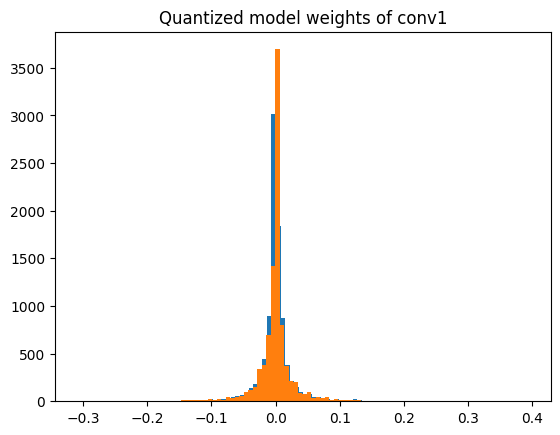

In [29]:
import matplotlib.pyplot as plt

f = wt_compare_dict['conv1.weight']['float'].flatten()
plt.hist(f, bins = 100)

q = wt_compare_dict['conv1.weight']['quantized'].flatten().dequantize()
plt.hist(q, bins = 100)
plt.title("Quantized model weights of conv1")
plt.show()

### RECOMMENDATIONS FOR YOUR WORKFLOW

![](https://drive.google.com/uc?export=view&id=1ij7GElwiKFNmJ221aKpkDRwMj5i-2DLh)



*   Large (10M+ parameters) models are more robust to quantization error
*   Quantizing a model from a FP32 checkpoint provides better accuracy than training an INT8 model from scratch
*   Dynamic Quantization is an easy first step, especially if your model has many Linear or Recurrent layers
*   Use symmetric-per-channel quantization with MinMax observers for quantizing weights. Use affine-per-tensor quantization with MovingAverageMinMax observers for quantizing activations
*   Use metrics like SQNR to identify which layers are most suscpetible to quantization error. Turn off quantization on these layers

Eager mode https://pytorch.org/docs/stable/quantization.html#eager-mode-quantization



*   https://pytorch.org/docs/stable/quantization.html#post-training-dynamic-quantization
*   https://pytorch.org/docs/stable/quantization.html#post-training-static-quantization


FX Graph https://pytorch.org/docs/stable/quantization.html#prototype-fx-graph-mode-quantization



*   https://pytorch.org/tutorials/prototype/fx_graph_mode_ptq_static.html
*   https://pytorch.org/tutorials/prototype/fx_graph_mode_ptq_dynamic.html





## New forkflow with torchao



In [ ]:
!pip install torchao

In [ ]:
import copy
import torch


class ToyLinearModel(torch.nn.Module):
    def __init__(self, m: int, n: int, k: int):
        super().__init__()
        self.linear1 = torch.nn.Linear(m, n, bias=False)
        self.linear2 = torch.nn.Linear(n, k, bias=False)

    def forward(self, x):
        x = self.linear1(x)
        x = self.linear2(x)
        return x


model = ToyLinearModel(1024, 1024, 1024).eval()
model_f32 = copy.deepcopy(model)


In [ ]:
import torchao
try:
    from torchao.quantization import Int4DynamicActivationInt4WeightConfig, quantize_

    quantize_(model, Int4DynamicActivationInt4WeightConfig())
    _torchao_quant_ok = True
except ImportError:
    _torchao_quant_ok = False


In [ ]:
if _torchao_quant_ok:
    from torchao.utils import benchmark_model

    num_runs = 20
    torch._dynamo.reset()
    example_inputs = (torch.randn(1, 1024, dtype=torch.float32),)
    f32_time = benchmark_model(model_f32, num_runs, example_inputs)
    int4_time = benchmark_model(model, num_runs, example_inputs)
    print("f32 mean time: %0.3f ms" % f32_time)
    print("int4 mean time: %0.3f ms" % int4_time)
    print("speedup: %0.1fx" % (f32_time / int4_time))


In [ ]:
import os

if _torchao_quant_ok:
    torch.save(model, "/tmp/int4_model.pt")
    torch.save(model_f32, "/tmp/f32_model.pt")
    int4_model_size_mb = os.path.getsize("/tmp/int4_model.pt") / 1024 / 1024
    f32_model_size_mb = os.path.getsize("/tmp/f32_model.pt") / 1024 / 1024
    print("int4 model size: %.2f MB" % int4_model_size_mb)
    print("f32 model size: %.2f MB" % f32_model_size_mb)


### Neural Network Compression Framework (NNCF)

In [ ]:

!git clone https://github.com/openvinotoolkit/nnc

In [ ]:
# %%capture
%cd nncf
!pip install .[torch]
%cd /content

In [ ]:
import torch
import nncf.torch  # Important - must be imported before any other external package that depends on torch

https://github.com/openvinotoolkit/nncf/tree/develop
https://github.com/openvinotoolkit/nncf/blob/develop/docs/compression_algorithms/Quantization.md
https://github.com/openvinotoolkit/nncf/blob/develop/examples/torch/classification/configs/quantization/inception_v3_imagenet_int8.json

https://dev-discuss.pytorch.org/t/torch-ao-quantization-migration-plan/2810
https://docs.pytorch.org/ao/stable

**Домашнее задание**: реализовать Post Training Quantization для предобученной float32 torch2 модели на выбранном наборе данных. Квантизация обязательно должна проводиться с использованием калибровочной подвыборки. К результатам прилагаются мини результаты исследования влияния гиперпараметров квантизации (см. начало ноутбка). Необходимо показать разные варианты с учетом и без SENSITIVITY анализа. Разрешается использовать дополнительные фреймворки после обсуждения. Важно наличие таблиц скорость / качество / размер.

### Homework

PTQ для `ResNet18` на CIFAR-10. Есть два режима квантизации: полная модель и только последний слой. 

Таблица: точность на тесте, время батча, размер файла.


In [39]:
import os
import time
import copy

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torch.ao.quantization import quantize_fx

torch.backends.quantized.engine = "fbgemm"

tfm = transforms.Compose(
    [transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]
)

train_full = datasets.CIFAR10(root="./data_cifar", train=True, download=True, transform=tfm)
test_ds = datasets.CIFAR10(root="./data_cifar", train=False, download=True, transform=tfm)

torch.manual_seed(0)


class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.seq = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.fc = nn.Linear(128, 10)

    def forward(self, x):
        x = self.seq(x).flatten(1)
        return self.fc(x)


def accuracy(m, dl, dev=torch.device("cpu")):
    m.eval()
    ok = tot = 0
    with torch.inference_mode():
        for xb, yb in dl:
            logits = m(xb.to(dev))
            ok += (logits.argmax(1).cpu() == yb).sum().item()
            tot += yb.size(0)
    return ok / tot


def bench_batch(m, xb, warmup=10, iters=30):
    m.eval()
    with torch.inference_mode():
        for _ in range(warmup):
            m(xb)
        t0 = time.perf_counter()
        for _ in range(iters):
            m(xb)
        return (time.perf_counter() - t0) / iters * 1000


def state_dict_bytes(sd):
    path = "_tmp_ptq_hw.pth"
    torch.save(sd, path)
    sz = os.path.getsize(path)
    os.remove(path)
    return sz


train_ds = Subset(train_full, torch.randperm(len(train_full))[:4096].tolist())
loader_train = DataLoader(train_ds, batch_size=128, shuffle=True)
loader_calib = DataLoader(Subset(train_full, list(range(256))), batch_size=32, shuffle=False)
loader_test = DataLoader(test_ds, batch_size=256, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_fp = SmallCNN().to(device)
opt = torch.optim.Adam(model_fp.parameters(), lr=1e-3)
crit = nn.CrossEntropyLoss()

model_fp.train()
for _ in range(1):
    for xb, yb in loader_train:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        crit(model_fp(xb), yb).backward()
        opt.step()

model_cpu = copy.deepcopy(model_fp).cpu().eval()
xb_sample, _ = next(iter(loader_test))

acc_fp = accuracy(model_cpu, loader_test)
ms_fp = bench_batch(model_cpu, xb_sample)


def ptq_static(qcfg):
    ex = (torch.randn(1, 3, 32, 32),)
    mq = quantize_fx.prepare_fx(copy.deepcopy(model_cpu), qcfg, ex)
    mq.eval()
    with torch.inference_mode():
        for xb, _ in loader_calib:
            mq(xb)
    return quantize_fx.convert_fx(mq)


q_all = ptq_static({"": torch.ao.quantization.get_default_qconfig("fbgemm")})
q_fc = ptq_static(
    {"": None, "module_name": [("fc", torch.ao.quantization.get_default_qconfig("fbgemm"))]}
)

acc_all = accuracy(q_all, loader_test)
acc_fc = accuracy(q_fc, loader_test)

ms_all = bench_batch(q_all, xb_sample)
ms_fc = bench_batch(q_fc, xb_sample)

sz_fp = state_dict_bytes(model_cpu.state_dict())
sz_all = state_dict_bytes(q_all.state_dict())
sz_fc = state_dict_bytes(q_fc.state_dict())

rows = [
    ("FP32", acc_fp, ms_fp, sz_fp),
    ("PTQ FX всё", acc_all, ms_all, sz_all),
    ("PTQ FX только fc", acc_fc, ms_fc, sz_fc),
]
print("")
print(f"{'Вариант':<18} {'Точность':>10} {'мс/батч':>12} {'байт':>12}")
for name, a, ms, sz in rows:
    print(f"{name:<18} {a:10.4f} {ms:12.3f} {sz:12}")



Вариант              Точность      мс/батч         байт
FP32                   0.2243      328.237       381893
PTQ FX всё             0.2168      196.385       107927
PTQ FX только fc       0.2165      357.229       380041

